In [1]:
import sys
import os
import math
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
from src.simulation import (
    simulate_sir,
    choose_immunized_random,
    choose_immunized_by_degree,
    choose_immunized_by_eigenvector_centrality,
    choose_immunized_by_betweenness_centrality,
    choose_immunized_by_adaptive_degree,
    choose_immunized_by_highest,
    choose_immunized_by_neighbor_nomination,
)
from src.data_processing import load_wy_county_graphs


In [2]:
BETA = 0.03
GAMMA = 0.03
STEPS = 200
N_INFECTED = 5
K_PERCENTAGES = list(range(0, 81, 10))
N_TRIALS = 10
BASE_SEED = 20260308

strategy_functions = {
    "Random": choose_immunized_random,
    "Degree": choose_immunized_by_degree,
    "Eigenvector": choose_immunized_by_eigenvector_centrality,
#    "Betweenness": choose_immunized_by_betweenness_centrality,
    "Adaptive Degree": choose_immunized_by_adaptive_degree,
    "Highest": choose_immunized_by_highest,
    "Neighbor Nomination": choose_immunized_by_neighbor_nomination,
}

DETERMINISTIC_STRATEGIES = {
    "Degree",
    "Eigenvector",
#    "Betweenness",
    "Adaptive Degree",
}

WY_BASE = Path("../data/WY")
county_dirs = sorted([p for p in WY_BASE.iterdir() if p.is_dir() and p.name.isdigit()])
print(f"Counties found: {len(county_dirs)}")
print("First 5:", [d.name for d in county_dirs[:5]])


Counties found: 23
First 5: ['56001', '56003', '56005', '56007', '56009']


In [3]:
# Quick data-loading sanity check (single county)
if not county_dirs:
    raise RuntimeError("No county folders found under ../data/WY")

sample_county = county_dirs[0]
B_sample, G_sample = load_wy_county_graphs(sample_county)
print("Sample county:", sample_county.name)
print("Bipartite nodes/edges:", B_sample.number_of_nodes(), B_sample.number_of_edges())
print("Person graph nodes/edges:", G_sample.number_of_nodes(), G_sample.number_of_edges())


Sample county: 56001
Bipartite nodes/edges: 43254 52417
Person graph nodes/edges: 28901 2758799


In [4]:
def stable_seed(*parts):
    key = "|".join(str(part) for part in parts)
    digest = hashlib.sha256(key.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % (2**32)


def run_single_trial(G, county_id, strategy_name, strategy_fn, k_count, trial_idx, immunized_override=None):
    seed0 = stable_seed(BASE_SEED, county_id, strategy_name, k_count, trial_idx)

    if immunized_override is None:
        random.seed(seed0)
        immunized = strategy_fn(G, k_count)
    else:
        immunized = immunized_override

    eligible = [node for node in G.nodes if node not in immunized]
    n_start = min(N_INFECTED, len(eligible))
    start_rng = random.Random(seed0 + 1)
    initial_infected = start_rng.sample(eligible, n_start) if n_start > 0 else []

    return simulate_sir(
        G,
        beta=BETA,
        gamma=GAMMA,
        steps=STEPS,
        initial_infected=initial_infected,
        immunized=immunized,
        rng=np.random.default_rng(seed0 + 2),
    )


def run_county_experiment(county_dir):
    county_id = county_dir.name
    _, G = load_wy_county_graphs(county_dir)
    pop = G.number_of_nodes()
    rows = []

    for k_pct in K_PERCENTAGES:
        k_count = math.floor(k_pct * pop / 100)

        for strategy_name, strategy_fn in strategy_functions.items():
            peaks, totals = [], []
            immunized_fixed = None
            # Deterministic strategies are computed once per (county, strategy, k).
            if strategy_name in DETERMINISTIC_STRATEGIES:
                immunized_fixed = strategy_fn(G, k_count)
            print(strategy_name)
            for trial_idx in range(N_TRIALS):
                out = run_single_trial(
                    G,
                    county_id,
                    strategy_name,
                    strategy_fn,
                    k_count,
                    trial_idx,
                    immunized_override=immunized_fixed,
                )
                peaks.append(max(out["I"]))
                totals.append(out["Total_inf"])
                print("iter" + str(trial_idx))

            rows.append({
                "county": county_id,
                "nodes": pop,
                "k_pct": k_pct,
                "k_count": k_count,
                "strategy": strategy_name,
                "peak_mean": float(np.mean(peaks)),
                "peak_std": float(np.std(peaks)),
                "total_mean": float(np.mean(totals)),
                "total_std": float(np.std(totals)),
            })

    return pd.DataFrame(rows)


In [5]:
if "county_dirs" not in globals() or not county_dirs:
    WY_BASE = Path("../data/WY")
    county_dirs = sorted([p for p in WY_BASE.iterdir() if p.is_dir() and p.name.isdigit()])

county_paths = [str(p) for p in county_dirs]
county_paths = [county_paths[0]]
print(f"Running {len(county_paths)} county (serial Monte Carlo)")

all_results = []
for idx, county_path in enumerate(county_paths, start=1):
    county_id = Path(county_path).name
    print(f"[{idx}/{len(county_paths)}] Running county {county_id}...")
    all_results.append(run_county_experiment(Path(county_path)))

results_df = pd.concat(all_results, ignore_index=True)
print("Done:", results_df.shape)
results_df.head()


Running 1 county (serial Monte Carlo)
[1/1] Running county 56001...
Random
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Degree
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Eigenvector
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Adaptive Degree
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Highest
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Neighbor Nomination
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Random
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Degree
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Eigenvector
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Adaptive Degree
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Highest
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Neighbor Nomination
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Random
iter0
iter1
iter2
iter3
iter4
iter5
iter6
iter7
iter8
iter9
Degre

,county,nodes,k_pct,k_count,strategy,peak_mean,peak_std,total_mean,total_std
0,56001,28901,0,0,Random,15292.7,88.553995,26044.1,57.829837
1,56001,28901,0,0,Degree,15372.6,103.973266,26067.0,77.099935
2,56001,28901,0,0,Eigenvector,15342.3,67.524884,26014.0,81.518096
3,56001,28901,0,0,Adaptive Degree,15339.4,99.152610,26033.4,65.241398
4,56001,28901,0,0,Highest,15304.4,102.653982,26042.9,63.665454


In [6]:
print(county_paths)

['../data/WY/56001']


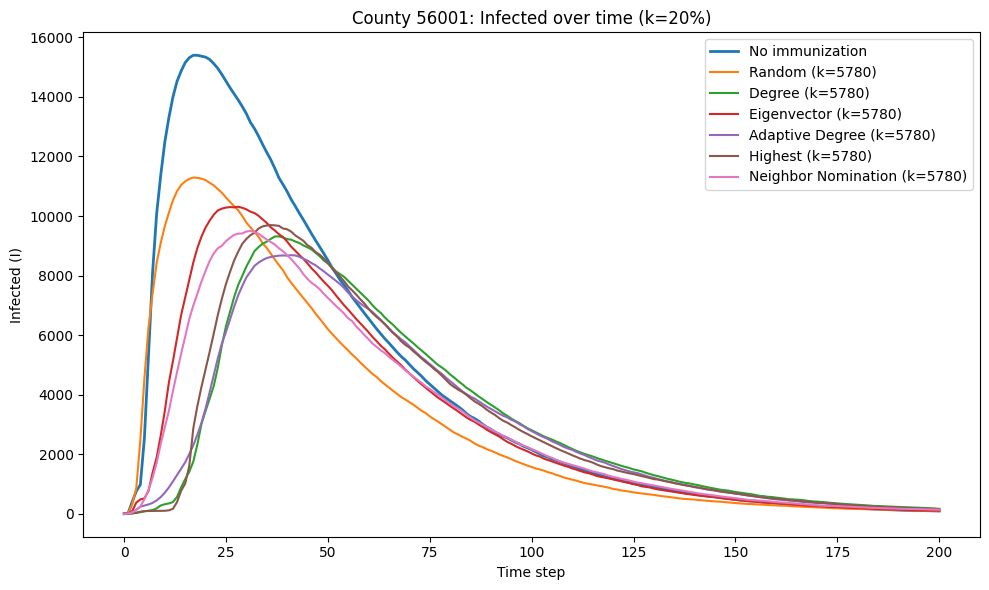

In [7]:
# Single-budget figure: infected over time by strategy
county_for_curve = Path(county_paths[0])
county_id_curve = county_for_curve.name
_, G_curve = load_wy_county_graphs(county_for_curve)

k_pct_curve = 20  # change as needed
k_count_curve = math.floor(k_pct_curve * G_curve.number_of_nodes() / 100)

# Baseline (no immunization)
seed_base = stable_seed(BASE_SEED, county_id_curve, "baseline", k_count_curve, 0)
start_rng = random.Random(seed_base + 1)
initial_infected_base = start_rng.sample(list(G_curve.nodes), min(N_INFECTED, G_curve.number_of_nodes()))

out_baseline = simulate_sir(
    G_curve,
    beta=BETA,
    gamma=GAMMA,
    steps=STEPS,
    initial_infected=initial_infected_base,
    immunized=set(),
    rng=np.random.default_rng(seed_base + 2),
)

out_by_strategy_curve = {}
for strategy_name, strategy_fn in strategy_functions.items():
    seed0 = stable_seed(BASE_SEED, county_id_curve, strategy_name, k_count_curve, 0)
    random.seed(seed0)
    immunized = strategy_fn(G_curve, k_count_curve)

    eligible = [node for node in G_curve.nodes if node not in immunized]
    n_start = min(N_INFECTED, len(eligible))
    start_rng = random.Random(seed0 + 1)
    initial_infected = start_rng.sample(eligible, n_start) if n_start > 0 else []

    out_by_strategy_curve[strategy_name] = simulate_sir(
        G_curve,
        beta=BETA,
        gamma=GAMMA,
        steps=STEPS,
        initial_infected=initial_infected,
        immunized=immunized,
        rng=np.random.default_rng(seed0 + 2),
    )

plt.figure(figsize=(10, 6))
plt.plot(out_baseline["I"], label="No immunization", linewidth=2)
for strategy_name, out in out_by_strategy_curve.items():
    plt.plot(out["I"], label=f"{strategy_name} (k={k_count_curve})")

plt.title(f"County {county_id_curve}: Infected over time (k={k_pct_curve}%)")
plt.xlabel("Time step")
plt.ylabel("Infected (I)")
plt.legend()
plt.tight_layout()
plt.show()


              strategy     avg_peak     avg_total
0      Adaptive Degree  4543.877778   8940.100000
1               Degree  5106.933333  10122.155556
3              Highest  5241.355556  10222.400000
4  Neighbor Nomination  5531.777778  10971.500000
2          Eigenvector  5852.022222  11517.277778
5               Random  7794.111111  13864.488889


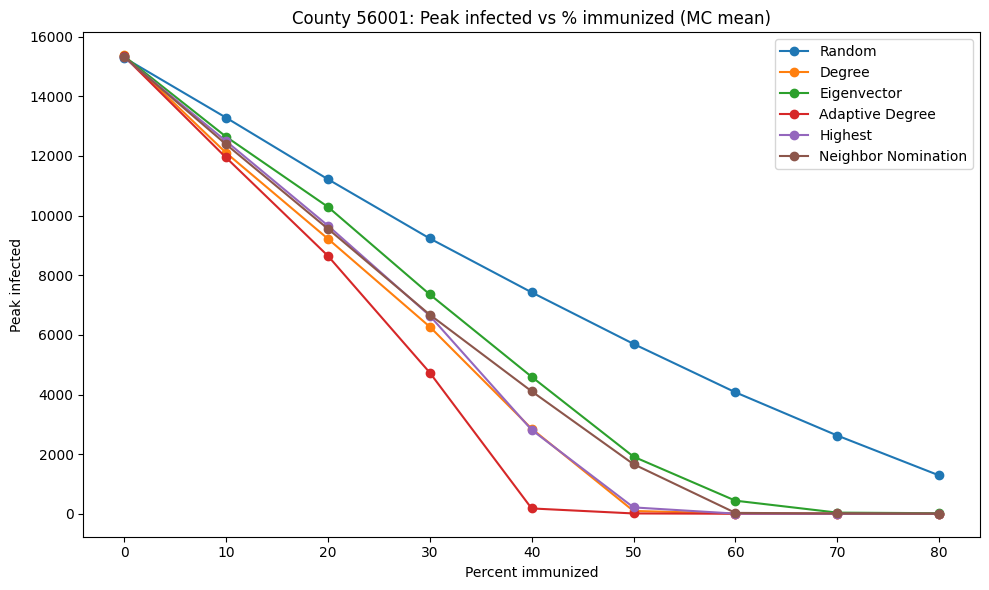

In [8]:
summary = (
    results_df.groupby(["county", "k_pct", "strategy"], as_index=False)
    .agg(peak_mean=("peak_mean", "mean"), total_mean=("total_mean", "mean"))
)

ranking = (
    summary.groupby("strategy", as_index=False)
    .agg(avg_peak=("peak_mean", "mean"), avg_total=("total_mean", "mean"))
    .sort_values("avg_peak")
)
print(ranking)

county_to_plot = county_dirs[0].name
subset = summary[summary["county"] == county_to_plot]

plt.figure(figsize=(10, 6))
for strategy_name in strategy_functions:
    s = subset[subset["strategy"] == strategy_name]
    plt.plot(s["k_pct"], s["peak_mean"], marker="o", label=strategy_name)

plt.title(f"County {county_to_plot}: Peak infected vs % immunized (MC mean)")
plt.xlabel("Percent immunized")
plt.ylabel("Peak infected")
plt.legend()
plt.tight_layout()
plt.show()
